In [3]:
import pickle
import os
import numpy as np
import pandas as pd
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
# from causallearn.utils.DataUtils import DataUtils
from causallearn.utils.GraphUtils import GraphUtils
from causallearn.search.FCMBased.lingam import DirectLiNGAM
import networkx as nx
import matplotlib.pyplot as plt

import seaborn as sns

/Users/sahithcherumandanda/anaconda3/envs/dsc180b/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
metis_fp = os.path.join('..', 'superblue', 'superblue_18', 'metis_part_dict.pkl')
f = open(metis_fp, 'rb')
metis_dict = pickle.load(f)
f.close()

node_features_fp = os.path.join('..', 'superblue', 'superblue_18', 'node_features.pkl')
f = open(node_features_fp, 'rb')
node_features_dict = pickle.load(f)
f.close()

pd_fp = os.path.join('..', 'superblue', 'superblue_18', 'node_neighbor_features.pkl')
f = open(pd_fp, 'rb')
pd_dict = pickle.load(f)
f.close()

targets_fp = os.path.join('..', 'superblue', 'superblue_18', 'targets.pkl')
f = open(targets_fp, 'rb')
targets_dict = pickle.load(f)
f.close()

In [5]:
node_features_dict

{'num_instances': 459495,
 'num_nets': 468888,
 'x_min': 5250,
 'x_max': 5716830,
 'y_min': 6660,
 'y_max': 5717610,
 'min_cell_width': 1920,
 'max_cell_width': 19211520,
 'min_cell_height': 13320,
 'max_cell_height': 20601600,
 'instance_features': array([[5.08445999e-01, 4.81049563e-01, 2.34000000e+02, 3.99800100e-04,
         0.00000000e+00, 6.00000000e+00],
        [5.08277920e-01, 4.81049563e-01, 1.89000000e+02, 3.99800100e-04,
         0.00000000e+00, 0.00000000e+00],
        [5.06933283e-01, 4.49562682e-01, 2.32000000e+02, 3.99800100e-04,
         0.00000000e+00, 6.00000000e+00],
        ...,
        [8.95869444e-01, 3.66763848e-01, 6.00000000e+00, 1.59920040e-03,
         0.00000000e+00, 0.00000000e+00],
        [8.97046001e-01, 3.67930029e-01, 6.00000000e+00, 1.59920040e-03,
         0.00000000e+00, 6.00000000e+00],
        [8.94524807e-01, 3.92419825e-01, 6.00000000e+00, 1.59920040e-03,
         0.00000000e+00, 0.00000000e+00]]),
 'sample_name': '/data/zluo/new_data/superblue

In [3]:
pd_dict['pd'].shape

(459495, 18)

In [4]:
pd_dict['neighbor'].shape

(459495, 12)

In [5]:
num_instances = node_features_dict['num_instances']

In [7]:
node_features_dict['num_instances'] + node_features_dict['num_nets']

928383

In [6]:
len(metis_dict)

928383

In [6]:
partition_28 = []
for key, value in metis_dict.items():
    if value == 28 and key < num_instances:
        partition_28.append(key)

In [7]:
X = pd_dict['pd'][partition_28]
y = targets_dict['demand'][partition_28]

In [8]:
feature_cols = [f"Feature_{i}" for i in range(X.shape[1])]
# Name for target
target_col = "Demand"

# Create DataFrame
df = pd.DataFrame(X, columns=feature_cols)
df[target_col] = y

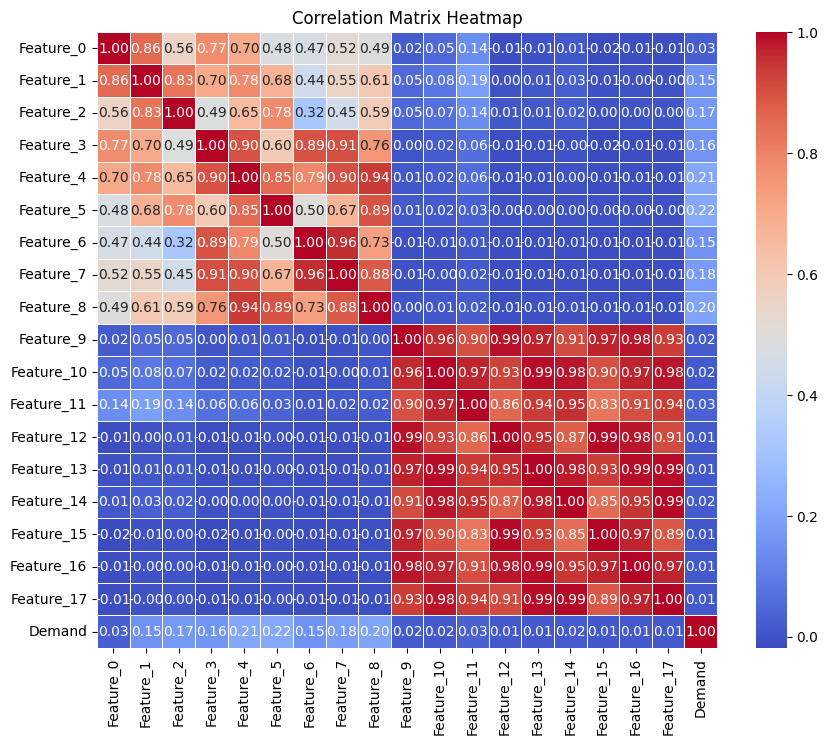

In [20]:
# Compute the correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(10, 8))  # Adjust figure size as needed
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [9]:
# Assume 'df' is our DataFrame with shape (2949, 7).
# Convert df to numpy array
data = df.values
data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)

# By default, PC will treat all variables as continuous
# If the columns have different data types, some additional steps may be required.

# Run PC
cg = pc(
    data,
    alpha=0.01,  # Significance level for conditional independence tests
    indep_test='fisherz'  # Fisher's z test for continuous variables
)

Depth=0, working on node 4:  26%|██▋       | 5/19 [00:00<00:00, 120.86it/s] 

Depth=4, working on node 18: 100%|██████████| 19/19 [00:00<00:00, 1896.38it/s]


In [10]:
# cg is a CausalGraph object
# Print out the adjacency information (edges)
# print("Edges (undirected before orientation):", cg.G.graph)

# Print the graph in a readable form
# GraphUtils.to_pydot(cg.G, labels=df.columns.tolist()).write("pc_graph.dot")

In [11]:
pyd = GraphUtils.to_pydot(cg.G, labels=df.columns.tolist())
pyd.write_png('pd_pc_instance_features.png')

In [12]:
# data is the same df.values
ges_graph = ges(data)

# Print edges
# print("GES Edges:", ges_graph.G.graph)

# Export the graph in dot format
# GraphUtils.to_pydot(ges_graph.G, labels=df.columns.tolist()).write("ges_graph.dot")
pyd = GraphUtils.to_pydot(ges_graph['G'], labels=df.columns.tolist())
pyd.write_png('pd_ges_instance_features.png')

In [15]:
model = DirectLiNGAM()
model.fit(data)

# Get the adjacency matrix
adj_matrix = model.adjacency_matrix_

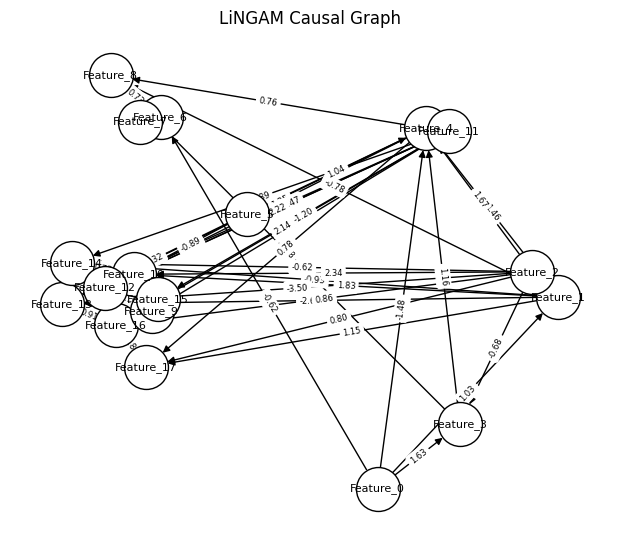

In [21]:
# Convert adjacency matrix to a directed graph using NetworkX
def adjacency_to_graph(adj_matrix, node_labels):
    G = nx.DiGraph()
    for i, source in enumerate(node_labels):
        for j, target in enumerate(node_labels):
            if abs(adj_matrix[i, j]) >= 0.5:  # Non-zero entries indicate a directed edge
                G.add_edge(source, target, weight=adj_matrix[i, j])
    return G

# Create a directed graph
node_labels = df.columns.to_list()
G = adjacency_to_graph(adj_matrix, node_labels)

# Visualize the graph
plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)  # Adjust for better visualization
nx.draw(G, pos, with_labels=True, node_size=1000, edgecolors='black', node_color="white", font_size=8)
nx.draw_networkx_edge_labels(
    G, pos, edge_labels={(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}, font_size=6
)
plt.title("LiNGAM Causal Graph")
plt.show()

In [24]:
df.columns[model.causal_order_]

Index(['Feature_8', 'Feature_6', 'Demand', 'Feature_14', 'Feature_12',
       'Feature_10', 'Feature_9', 'Feature_13', 'Feature_15', 'Feature_16',
       'Feature_11', 'Feature_17', 'Feature_4', 'Feature_3', 'Feature_2',
       'Feature_1', 'Feature_5', 'Feature_7', 'Feature_0'],
      dtype='object')